In [ ]:
# STUDENT DATASET
#importing libraries & Loading Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
display(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nDataset Info:")
df.info()

✅ Dataset loaded successfully!


,StudentID,Gender,Age,Class,StudyHours,AttendanceRate,HomeworkCompletion,MidtermScore,FinalScore,OverallScore,Passed
0,S1000,Male,13,10,7.4,99.1,91.0,58.5,63.7,64.4,Yes
1,S1001,Female,13,11,4.7,89.9,96.3,61.6,61.5,65.0,Yes
2,S1002,Male,15,11,5.3,85.5,72.2,84.1,61.3,71.5,Yes
3,S1003,Male,18,9,4.0,85.5,69.5,92.8,81.4,84.8,Yes
4,S1004,Male,14,10,2.7,85.5,97.5,50.9,75.6,67.9,Yes



Dataset Shape: (300, 11)

Column Names: ['StudentID', 'Gender', 'Age', 'Class', 'StudyHours', 'AttendanceRate', 'HomeworkCompletion', 'MidtermScore', 'FinalScore', 'OverallScore', 'Passed']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           300 non-null    object 
 1   Gender              300 non-null    object 
 2   Age                 300 non-null    int64  
 3   Class               300 non-null    int64  
 4   StudyHours          300 non-null    float64
 5   AttendanceRate      300 non-null    float64
 6   HomeworkCompletion  300 non-null    float64
 7   MidtermScore        300 non-null    float64
 8   FinalScore          300 non-null    float64
 9   OverallScore        300 non-null    float64
 10  Passed              300 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage

In [ ]:
# ======================================
# ADVANCED PREPROCESSING PIPELINE
# ======================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# -------------------------
# Load dataset
# -------------------------

# Correcting the file path to point to the dataset in Google Drive
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

print("📌 Initial Dataset loaded for preprocessing.")

# -------------------------
# Missing Value Summary
# -------------------------

print("\n📌 Missing Values Before Preprocessing:")
print(df.isnull().sum())

# ======================================
# 1️⃣ HANDLE MISSING VALUES
# ======================================

# Numeric columns → fill with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n📌 Missing Values After Filling:")
print(df.isnull().sum())

# ======================================
# 2️⃣ OUTLIER REMOVAL (IQR METHOD)
# ======================================

def remove_outliers_IQR(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

for col in num_cols:
    df = remove_outliers_IQR(df, col)

print("\n📌 After Removing Outliers:")
print(df.describe())

# ======================================
# 3️⃣ LABEL ENCODING (for categorical columns)
# ======================================

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\n📌 After Label Encoding:")
# display(df.head()) # Removed duplicate output

# ======================================
# 4️⃣ FEATURE SCALING (Min-Max Normalization)
# ======================================

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\n📌 After Feature Scaling:")
# display(df.head()) # Removed duplicate output

# ======================================
# 5️⃣ SAVE CLEANED DATASET
# ======================================

df.to_csv("student_performance_cleaned_advanced.csv", index=False)

print("\n🎉 Advanced Preprocessing Completed!")
print("📁 File saved as: student_performance_cleaned_advanced.csv")

📌 Initial Dataset loaded for preprocessing.

📌 Missing Values Before Preprocessing:
StudentID             0
Gender                0
Age                   0
Class                 0
StudyHours            0
AttendanceRate        0
HomeworkCompletion    0
MidtermScore          0
FinalScore            0
OverallScore          0
Passed                0
dtype: int64

📌 Missing Values After Filling:
StudentID             0
Gender                0
Age                   0
Class                 0
StudyHours            0
AttendanceRate        0
HomeworkCompletion    0
MidtermScore          0
FinalScore            0
OverallScore          0
Passed                0
dtype: int64

📌 After Removing Outliers:
              Age       Class  StudyHours  AttendanceRate  HomeworkCompletion  \
count  289.000000  289.000000  289.000000      289.000000          289.000000   
mean    15.536332   10.041522    5.112457       90.612111           84.743253   
std      1.741914    1.471372    2.132955        5.093224 

In [ ]:
!pip install altair vega_datasets


In [ ]:
##vizualization##

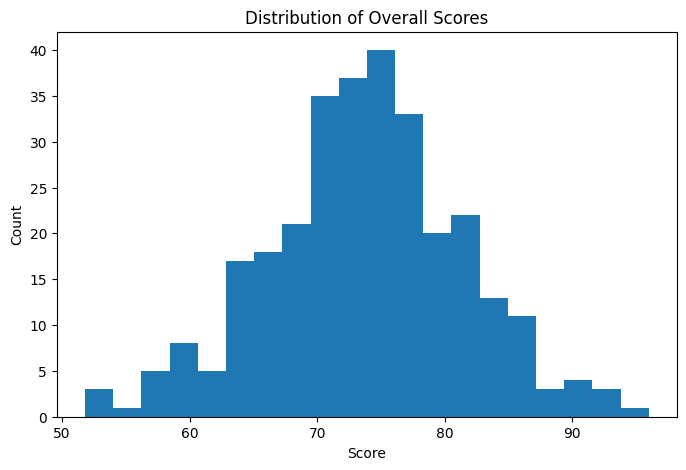

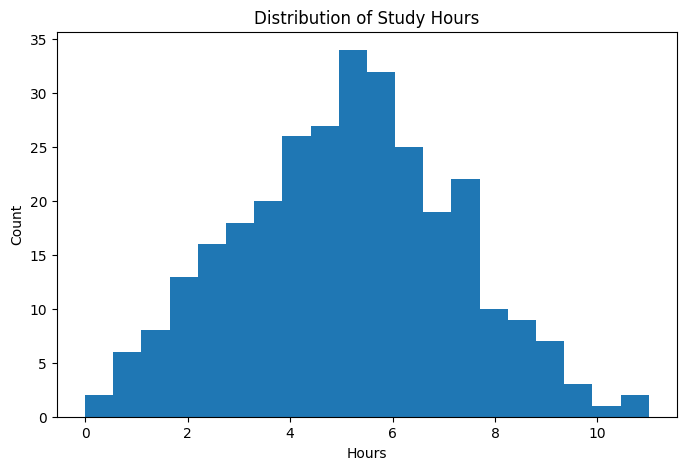

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

plt.figure(figsize=(8,5))
plt.hist(df["OverallScore"], bins=20)
plt.title("Distribution of Overall Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["StudyHours"], bins=20)
plt.title("Distribution of Study Hours")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

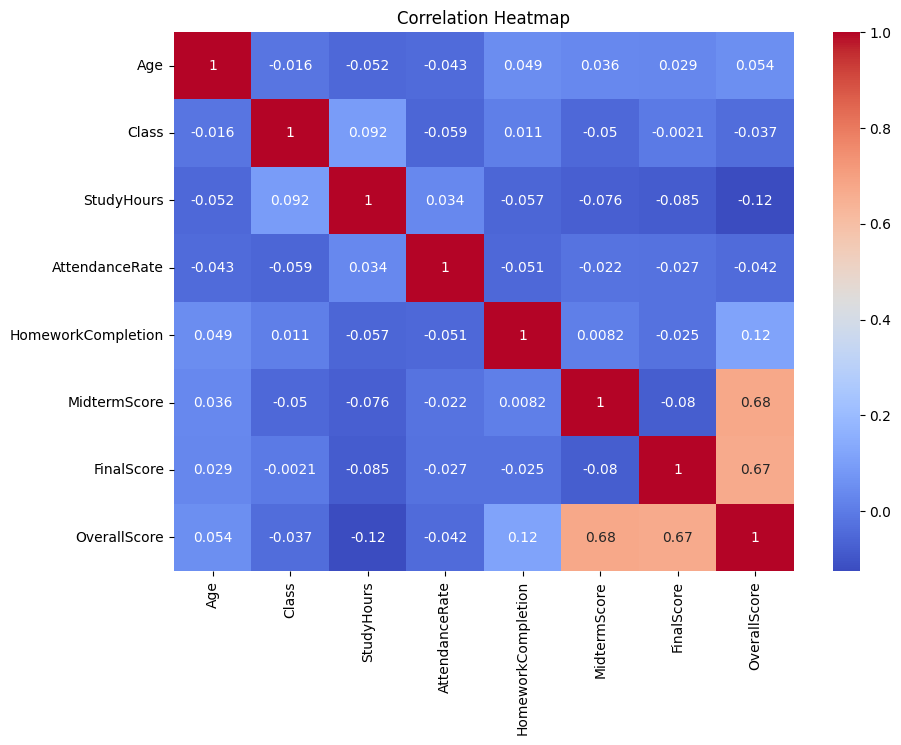

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

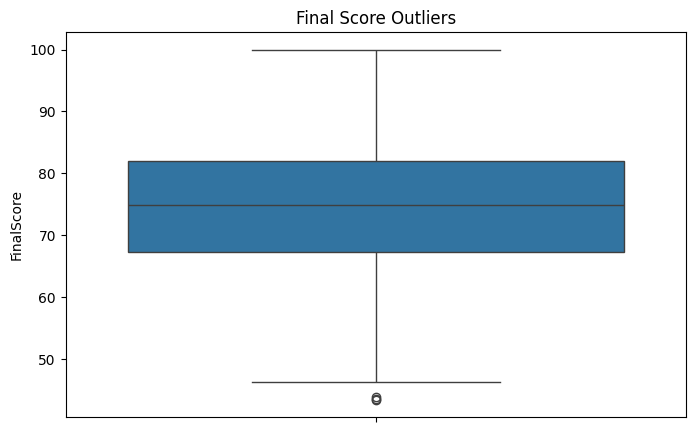

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

plt.figure(figsize=(8,5))
sns.boxplot(df["FinalScore"])
plt.title("Final Score Outliers")
plt.show()

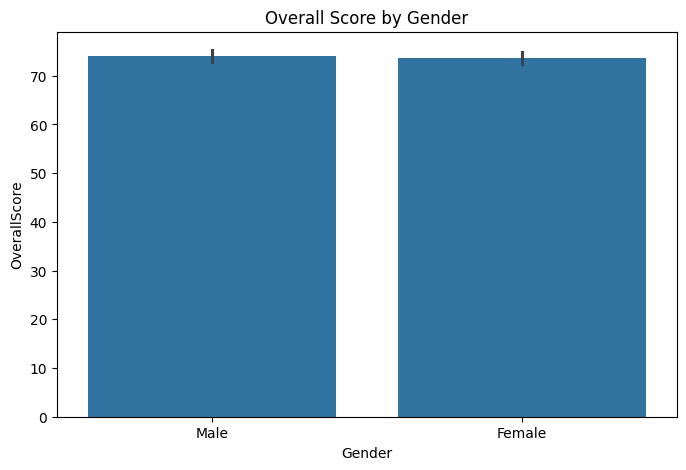

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

plt.figure(figsize=(8,5))
sns.barplot(x="Gender", y="OverallScore", data=df)
plt.title("Overall Score by Gender")
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

fig = px.scatter(
    df,
    x="StudyHours",
    y="OverallScore",
    color="Gender",
    title="Interactive: Study Hours vs Overall Score",
    hover_data=["Class", "AttendanceRate"]
)
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

fig = px.scatter_3d(
    df,
    x="StudyHours",
    y="AttendanceRate",
    z="OverallScore",
    color="Gender",
    title="3D Interactive: Study Hours vs Attendance vs Score"
)
fig.show()

In [ ]:
#questionnaire#

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [ ]:
#Q1 — What is the distribution of students' Overall Score?
import plotly.express as px

fig = px.histogram(df, x="OverallScore", nbins=20,
                   title="Distribution of Overall Score",
                   marginal="box", color="Gender")
fig.show()


In [ ]:
#Q2 — How does average Attendance Rate vary across classes?
att_class = df.groupby("Class")["AttendanceRate"].mean().reset_index()

fig = px.bar(att_class, x="Class", y="AttendanceRate",
             title="Average Attendance Rate per Class",
             color="Class")
fig.show()


In [ ]:
#Q3 — What is the relationship between Midterm Score and Final Score?
fig = px.scatter(df, x="MidtermScore", y="FinalScore",
                 color="Gender",
                 title="Relationship Between Midterm and Final Scores")
fig.show()


In [ ]:
#Q4 How are the various factors in the dataset related to each other?
import plotly.figure_factory as ff
import pandas as pd
import numpy as np
from google.colab import drive

# Ensure Google Drive is mounted for file access
drive.mount('/content/drive', force_remount=True)

# Ensure df is loaded within this cell's scope
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

# 1. Select ONLY numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Compute correlation properly
corr = numeric_df.corr()

# 3. Remove ANY rows/cols with all NaN (safety)
corr = corr.dropna(axis=0, how='all')
corr = corr.dropna(axis=1, how='all')

# Round correlation values for better annotation display
corr_rounded = corr.round(2);

# 4. Create a clean annotated heatmap
fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.columns),
    annotation_text=corr_rounded.values, # Use rounded values for annotations
    colorscale='Viridis',
    showscale=True
)

fig.update_layout(
    title="Correlation Heatmap",
    xaxis=dict(title="Attributes"),
    yaxis=dict(title="Attributes"),
    width=800,  # Increased width for better spacing
    height=700  # Increased height for better spacing
)

fig.show()

MessageError: Error: credential propagation was unsuccessful

In [ ]:
#Q5 — How does attendance percentage influence Overall Score (CGPA equivalent)?
import pandas as pd
import plotly.express as px

# Ensure df is loaded in this cell's scope
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

fig = px.scatter(df, x="AttendanceRate", y="OverallScore",
                 color="Class", # Using 'Class' as equivalent to 'Department_Branch'
                 title="Relationship Between Attendance Rate and Overall Score",
                 trendline="ols")
fig.show()


In [ ]:
#Q6  How does CGPA vary among branches?
import pandas as pd
import plotly.express as px

# Ensure df is loaded in this cell's scope
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

fig = px.box(df, x="Class", y="OverallScore",
             title="Overall Score Distribution per Class",
             color="Class")
fig.show()

In [ ]:
#Q7 — Who are the top 15 students based on CGPA?
import pandas as pd
import plotly.express as px

# Ensure df is loaded in this cell's scope
file_path = '/content/drive/MyDrive/student_performance_dataset_link_version.csv'
df = pd.read_csv(file_path)

top15 = df.sort_values(by="OverallScore", ascending=False).head(15)

fig = px.bar(top15, x="StudentID", y="OverallScore",
             title="Top 15 Students by Overall Score",
             color="Class") # Assuming 'Class' is equivalent to 'Department_Branch'
fig.show()